<a href="https://colab.research.google.com/github/Vinutha-Reddy/Internship-Projects/blob/main/Project_07_KMeans_Customer_Purchasing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Project Title - Customer Purchasing Behaviors**

# **2. Problem Statement**
In today’s competitive market, businesses need to understand their customers to deliver
personalized experiences and increase revenue. However, customers differ in terms of age,
income, purchasing habits, and loyalty, making it difficult to target them effectively.
This project aims to analyze customer purchasing behavior using features such as age, annual
income, purchase amount, purchase frequency, region, and loyalty score. The objective is to
group customers into meaningful segments based on their similarities.
By performing customer segmentation, businesses can:
- Identify high-value and low-value customers
- Design targeted marketing strategies
- Improve customer retention and loyalty
- Optimize product recommendations

The dataset used is synthetic and created for learning purposes.

# **3. Project Objectives**
The objective of this task is to:
- Understand and explore the customer purchasing behaviours dataset
- Perform data preprocessing (missing values, duplicates, outliers)
- Conduct Exploratory Data Analysis (EDA)
- Apply encoding and feature scaling
- Apply K-Means clustering and evaluate

# **4. Tools and Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **5. Dataset Loading**

In [ ]:
data = pd.read_csv('Customer Purchasing Behaviors.csv')
data

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,North,12
1,2,34,55000,350,7.0,South,18
2,3,45,65000,500,8.0,West,22
3,4,22,30000,150,3.0,East,10
4,5,29,47000,220,4.8,North,13
...,...,...,...,...,...,...,...
233,234,40,60000,450,7.2,West,20
234,235,38,59000,430,6.9,North,20
235,236,54,74000,630,9.4,South,27
236,237,32,52000,360,5.8,West,18


# **6. Preliminary Data Exploration**

In [ ]:
# Dataset Shape
data.shape

(238, 7)

There are **238 rows** and **7 columns**

In [ ]:
# Head
data.head()

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,North,12
1,2,34,55000,350,7.0,South,18
2,3,45,65000,500,8.0,West,22
3,4,22,30000,150,3.0,East,10
4,5,29,47000,220,4.8,North,13


In [ ]:
# Tail
data.tail()

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
233,234,40,60000,450,7.2,West,20
234,235,38,59000,430,6.9,North,20
235,236,54,74000,630,9.4,South,27
236,237,32,52000,360,5.8,West,18
237,238,31,51000,340,5.6,North,17


In [ ]:
# Dataset Information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             238 non-null    int64  
 1   age                 238 non-null    int64  
 2   annual_income       238 non-null    int64  
 3   purchase_amount     238 non-null    int64  
 4   loyalty_score       238 non-null    float64
 5   region              238 non-null    object 
 6   purchase_frequency  238 non-null    int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 13.1+ KB


In [ ]:
# Data Types
data.dtypes

,0
user_id,int64
age,int64
annual_income,int64
purchase_amount,int64
loyalty_score,float64
region,object
purchase_frequency,int64


In [ ]:
# Statistical Summary
# Numeric Columns
num_data=data.select_dtypes(include=['int64','float64'])
num_data

,user_id,age,annual_income,purchase_amount,loyalty_score,purchase_frequency
0,1,25,45000,200,4.5,12
1,2,34,55000,350,7.0,18
2,3,45,65000,500,8.0,22
3,4,22,30000,150,3.0,10
4,5,29,47000,220,4.8,13
...,...,...,...,...,...,...
233,234,40,60000,450,7.2,20
234,235,38,59000,430,6.9,20
235,236,54,74000,630,9.4,27
236,237,32,52000,360,5.8,18


In [ ]:
# Statistical report of Numerical data
data.describe()

,user_id,age,annual_income,purchase_amount,loyalty_score,purchase_frequency
count,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000
mean,119.500000,38.676471,57407.563025,425.630252,6.794118,19.798319
std,68.848868,9.351118,11403.875717,140.052062,1.899047,4.562884
min,1.000000,22.000000,30000.000000,150.000000,3.000000,10.000000
25%,60.250000,31.000000,50000.000000,320.000000,5.500000,17.000000
50%,119.500000,39.000000,59000.000000,440.000000,7.000000,20.000000
75%,178.750000,46.750000,66750.000000,527.500000,8.275000,23.000000
max,238.000000,55.000000,75000.000000,640.000000,9.500000,28.000000


In [ ]:
# Categorical Columns
cat_data=data.select_dtypes(include=['object'])
cat_data

,region
0,North
1,South
2,West
3,East
4,North
...,...
233,West
234,North
235,South
236,West


In [ ]:
data.describe(include='object')

,region
count,238
unique,4
top,North
freq,78


In [ ]:
data.columns

Index(['user_id', 'age', 'annual_income', 'purchase_amount', 'loyalty_score',
       'region', 'purchase_frequency'],
      dtype='object')

In [ ]:
# Unique Values
df = data[['region','purchase_frequency','loyalty_score']]
for x in df:
    print(f"{x} --> {df[x].unique()}")
    print()

region --> ['North' 'South' 'West' 'East']

purchase_frequency --> [12 18 22 10 13 21 19 14 25 17 15 23 20 24 11 16 26 28 27]

loyalty_score --> [4.5 7.  8.  3.  4.8 7.8 6.5 4.2 9.  5.5 4.4 8.2 6.  6.8 8.9 3.2 5.  8.1
 4.3 9.2 3.3 7.5 6.2 6.9 8.3 5.8 4.6 7.2 4.  9.5 8.5 9.3 9.4 5.6 7.7]



In [ ]:
# Value Counts
for x in df:
    print(df[x].value_counts())
    print()

region
North    78
South    77
West     77
East      6
Name: count, dtype: int64

purchase_frequency
21    24
22    23
18    23
20    23
14    23
25    21
24    15
11    14
19    10
17     9
16     8
27     8
26     8
15     8
23     8
28     7
12     3
13     2
10     1
Name: count, dtype: int64

loyalty_score
9.0    21
7.8    15
4.3    14
3.3    14
6.0    14
7.0     9
6.5     9
8.1     8
8.0     8
6.8     8
8.9     8
6.9     8
5.0     8
9.2     8
7.2     8
4.2     8
5.8     8
9.4     7
8.2     7
8.5     7
5.6     7
4.0     7
9.5     7
7.7     6
4.5     2
5.5     2
4.4     2
3.2     1
4.8     1
3.0     1
6.2     1
4.6     1
8.3     1
7.5     1
9.3     1
Name: count, dtype: int64



In [ ]:
data

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,North,12
1,2,34,55000,350,7.0,South,18
2,3,45,65000,500,8.0,West,22
3,4,22,30000,150,3.0,East,10
4,5,29,47000,220,4.8,North,13
...,...,...,...,...,...,...,...
233,234,40,60000,450,7.2,West,20
234,235,38,59000,430,6.9,North,20
235,236,54,74000,630,9.4,South,27
236,237,32,52000,360,5.8,West,18


# **7. Data Cleaning and Preparation**

**7.1 Duplicate Handling**

In [ ]:
data.duplicated().sum()

np.int64(0)

There are **no duplicate values** in the data.

**7.2 Missing Value Treatment**

In [ ]:
data.isnull().sum()

,0
user_id,0
age,0
annual_income,0
purchase_amount,0
loyalty_score,0
region,0
purchase_frequency,0


There are **no missing values** in the data.

# **8. Data Visualization and Analysis**

**8.1 Univariate Analysis**

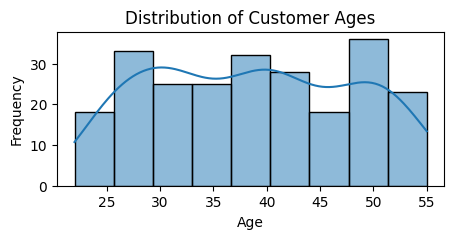

In [ ]:
# Distribution of customer ages
plt.figure(figsize=(5, 2))
sns.histplot(data['age'], kde=True)
plt.title('Distribution of Customer Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

**Insights**

* The **age distribution** is fairly **uniform**, indicating customers are spread across multiple age groups rather than concentrated in one.

* There is a slight **peak around 25–30 and 45–50**, showing higher **customer frequency** in these ranges.

* The **middle age group (30–45)** maintains a **consistent presence**, suggesting steady engagement from this segment.

* Very **young (below 25)** and **older (above 55)** age groups have **lower frequency**, indicating fewer customers in these extremes.


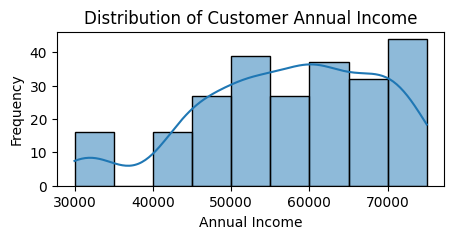

In [ ]:
# How is customer income distributed
plt.figure(figsize=(5, 2))
sns.histplot(data['annual_income'], kde=True)
plt.title('Distribution of Customer Annual Income')
plt.xlabel('Annual Income')
plt.ylabel('Frequency')
plt.show()

**Insights**

* The **income distribution** is slightly **right-skewed**, indicating more customers fall in the **higher income ranges**.

* A noticeable **peak around 55K–70K** suggests this is the **dominant income group** among customers.

* The **mid-income range (45K–60K)** shows **consistent frequency**, indicating a stable customer base in this segment.

* The **lower income range (30K–40K)** has **fewer customers**, highlighting lower representation in this category.


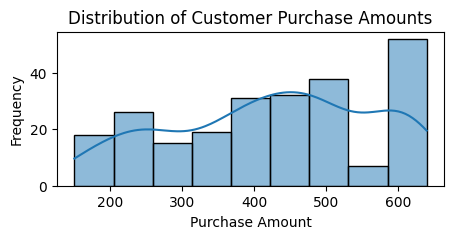

In [ ]:
# What is the spending pattern of customers
plt.figure(figsize=(5, 2))
sns.histplot(data['purchase_amount'], kde=True)
plt.title('Distribution of Customer Purchase Amounts')
plt.xlabel('Purchase Amount')
plt.ylabel('Frequency')
plt.show()

**Insights**

* The **purchase amount distribution** is slightly **right-skewed**, indicating more transactions occur at **higher values**.

* A clear **peak around 400–500** shows this is the **most common spending range** among customers.

* The **mid-range (300–500)** has **consistent frequency**, suggesting steady purchasing behavior in this segment.

* The **lower purchase range (150–250)** has **fewer transactions**, indicating limited low-value purchases.


**8.2 Bivariate Analysis**

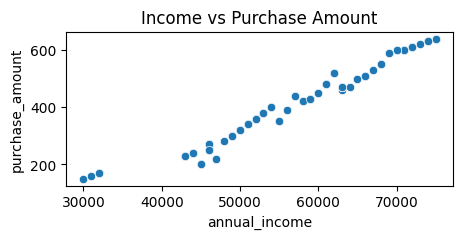

In [ ]:
# Do customers with higher income spend more
plt.figure(figsize=(5, 2))
sns.scatterplot(x='annual_income', y='purchase_amount', data=data)
plt.title("Income vs Purchase Amount")
plt.show()

**Insights**

* There is a strong **positive correlation** between **income** and **purchase amount**, indicating higher earners spend more.

* As **annual income increases**, the **purchase amount rises consistently**, showing a clear upward trend.

* The data points are closely aligned, suggesting a **strong linear relationship** with minimal variation.

* Lower income groups (around **30K–45K**) have **significantly lower purchases**, while higher income groups (above **60K**) show **higher spending levels**.


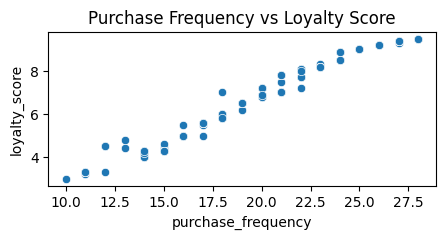

In [ ]:
# Does higher purchase frequency lead to higher loyalty scores
plt.figure(figsize=(5, 2))
sns.scatterplot(x='purchase_frequency', y='loyalty_score', data=data)
plt.title("Purchase Frequency vs Loyalty Score")
plt.show()

**Insights**

* There is a strong **positive relationship** between **purchase frequency** and **loyalty score**, indicating frequent buyers are more loyal.

* As **purchase frequency increases**, the **loyalty score steadily rises**, showing consistent customer engagement.

* The data points follow a clear **upward trend**, suggesting a **strong correlation** with minimal fluctuations.

* Customers with **low frequency (10–15)** have **lower loyalty**, while those with **high frequency (20+)** exhibit **significantly higher loyalty scores**.


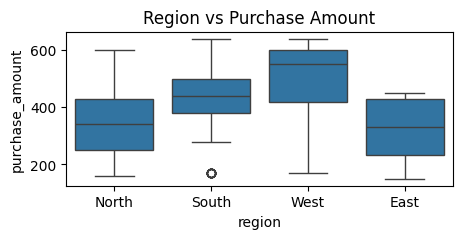

In [ ]:
# Do customers from different regions behave differently
plt.figure(figsize=(5, 2))
sns.boxplot(x='region', y='purchase_amount', data=data)
plt.title("Region vs Purchase Amount")
plt.show()

**Insights**

* **West region** shows the **highest median purchase amount**, indicating **stronger customer spending** compared to others.
* **South region** has a **moderately high median** with a **visible outlier**, suggesting occasional **very low purchases**.
* **North and East regions** have **lower median values**, indicating **comparatively weaker sales performance**.
* **West and North** display a **larger spread (variability)**, meaning **purchase amounts fluctuate more** in these regions.


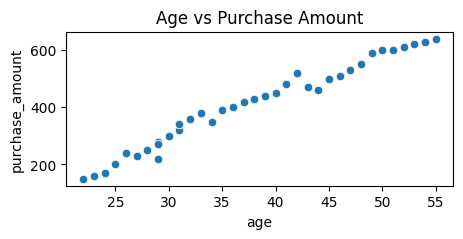

In [ ]:
# Does age influence purchasing behavior
plt.figure(figsize=(5, 2))
sns.scatterplot(x='age', y='purchase_amount', data=data)
plt.title("Age vs Purchase Amount")
plt.show()

**Insights**

* There is a clear **positive relationship** between **age and purchase amount**, showing **spending increases with age**.
* Younger age group (around **22–30**) has **lower purchase values**, indicating **limited spending capacity**.
* Middle age group (**30–45**) shows a **steady increase**, reflecting **growing purchasing power**.
* Older age group (**45+**) reaches the **highest purchase amounts**, indicating **maximum spending behavior**.


# **9. Detect and Handle Outliers**

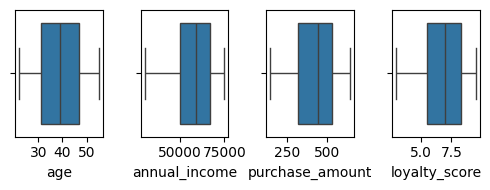

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(5,2))
sns.boxplot(data=data, x='age', ax=ax[0])
sns.boxplot(data=data, x='annual_income', ax=ax[1])
sns.boxplot(data=data, x='purchase_amount', ax=ax[2])
sns.boxplot(data=data, x='loyalty_score', ax=ax[3])

plt.tight_layout()
plt.show()

There are **no outliers** in the data

# **10. Encoding**

In [ ]:
data.dtypes

,0
user_id,int64
age,int64
annual_income,int64
purchase_amount,int64
loyalty_score,float64
region,object
purchase_frequency,int64


**region - One-Hot Encoding**

In [ ]:
data = pd.get_dummies(data, columns=['region'],dtype='int')

In [ ]:
data.dtypes

,0
user_id,int64
age,int64
annual_income,int64
purchase_amount,int64
loyalty_score,float64
purchase_frequency,int64
region_East,int64
region_North,int64
region_South,int64
region_West,int64


In [ ]:
data

,user_id,age,annual_income,purchase_amount,loyalty_score,purchase_frequency,region_East,region_North,region_South,region_West
0,1,25,45000,200,4.5,12,0,1,0,0
1,2,34,55000,350,7.0,18,0,0,1,0
2,3,45,65000,500,8.0,22,0,0,0,1
3,4,22,30000,150,3.0,10,1,0,0,0
4,5,29,47000,220,4.8,13,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
233,234,40,60000,450,7.2,20,0,0,0,1
234,235,38,59000,430,6.9,20,0,1,0,0
235,236,54,74000,630,9.4,27,0,0,1,0
236,237,32,52000,360,5.8,18,0,0,0,1


# **11. Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler
num_cols = ['age','annual_income','purchase_amount','loyalty_score','purchase_frequency']
scaler = StandardScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

In [ ]:
data

,user_id,age,annual_income,purchase_amount,loyalty_score,purchase_frequency,region_East,region_North,region_South,region_West
0,1,-1.465632,-1.090306,-1.614441,-1.210582,-1.712679,0,1,0,0
1,2,-0.501151,-0.211563,-0.541153,0.108642,-0.394950,0,0,1,0
2,3,0.677658,0.667180,0.532134,0.636332,0.483536,0,0,0,1
3,4,-1.787125,-2.408420,-1.972203,-2.002117,-2.151922,1,0,0,0
4,5,-1.036974,-0.914557,-1.471336,-1.052275,-1.493057,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
233,234,0.141835,0.227809,0.174372,0.214180,0.044293,0,0,0,1
234,235,-0.072494,0.139934,0.031267,0.055873,0.044293,0,1,0,0
235,236,1.642138,1.458049,1.462317,1.375097,1.581644,0,0,1,0
236,237,-0.715480,-0.475186,-0.469601,-0.524586,-0.394950,0,0,0,1


# **12. Feature Selection**

In [ ]:
df=data[['annual_income','purchase_amount','purchase_frequency','loyalty_score']]

In [ ]:
df.columns

Index(['annual_income', 'purchase_amount', 'purchase_frequency',
       'loyalty_score'],
      dtype='object')

# **13. K-Means**

**a. Fit model with different values of K**

In [ ]:
from sklearn.cluster import KMeans
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df)
    inertia.append(kmeans.inertia_)

**b. Assign cluster labels to customers**

In [ ]:
df.loc[:, 'cluster'] = kmeans.fit_predict(df)
df

/tmp/ipykernel_38617/693433081.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'cluster'] = kmeans.fit_predict(df)


,annual_income,purchase_amount,purchase_frequency,loyalty_score,cluster
0,-1.090306,-1.614441,-1.712679,-1.210582,1
1,-0.211563,-0.541153,-0.394950,0.108642,4
2,0.667180,0.532134,0.483536,0.636332,7
3,-2.408420,-1.972203,-2.151922,-2.002117,3
4,-0.914557,-1.471336,-1.493057,-1.052275,1
...,...,...,...,...,...
233,0.227809,0.174372,0.044293,0.214180,2
234,0.139934,0.031267,0.044293,0.055873,2
235,1.458049,1.462317,1.581644,1.375097,0
236,-0.475186,-0.469601,-0.394950,-0.524586,4


**c. Evaluate**

In [ ]:
# Silhouette score
from sklearn.metrics import silhouette_score
score = silhouette_score(df, df['cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.8839136347101041


**d. Use Elbow method to choose best k value**

In [ ]:
new_data = df.drop(columns='cluster')

In [ ]:
wcss = []
for k in range(2,11):
  model = KMeans(n_clusters=k)
  model.fit(new_data)
  wcss.append(model.inertia_)
print(wcss)

[274.8640553532436, 123.94384800974267, 66.72110814998399, 41.127508946628154, 27.561062294359964, 20.79462702857917, 16.86534404922754, 12.132669435372495, 11.01719716747187]


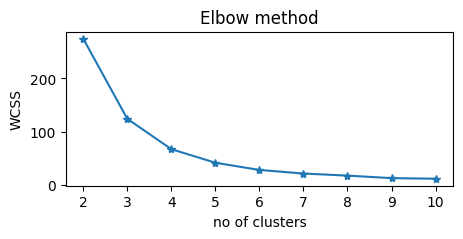

In [ ]:
plt.figure(figsize=(5,2))
plt.plot(range(2,11),wcss,marker='*')
plt.xlabel('no of clusters')
plt.ylabel('WCSS')
plt.title('Elbow method')
plt.show()

In [ ]:
new_data

,annual_income,purchase_amount,purchase_frequency,loyalty_score
0,-1.090306,-1.614441,-1.712679,-1.210582
1,-0.211563,-0.541153,-0.394950,0.108642
2,0.667180,0.532134,0.483536,0.636332
3,-2.408420,-1.972203,-2.151922,-2.002117
4,-0.914557,-1.471336,-1.493057,-1.052275
...,...,...,...,...
233,0.227809,0.174372,0.044293,0.214180
234,0.139934,0.031267,0.044293,0.055873
235,1.458049,1.462317,1.581644,1.375097
236,-0.475186,-0.469601,-0.394950,-0.524586


In [ ]:
model = KMeans(n_clusters=4)
model.fit(new_data)
labels = model.predict(new_data)

In [ ]:
silhouette_score(new_data,labels)

np.float64(0.57909629536122)